<a href="https://colab.research.google.com/github/Dandyeriametor/Activity/blob/main/Assignment_15_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 15: Loan Default Prediction

Author: Dandy Eriametor

Business Intelligence Analyst

Student Number: DE111080

# Bank Loan Default Prediction – Fairness and Explainability

This Colab notebook walks through the full assignment:



*   Task 1: Data loading, cleaning, EDA
*   Task 2: Feature engineering and scaling


*   Task 3: Model building and evaluation (Random Forest)
*   Task 4: SHAP explainability and fairness analysis

*   Task 5: Ethical considerations (short written discussion)








In [1]:
# Import all the required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

import shap

## Task 1 – Data Loading, Cleaning, and EDA

In [3]:
# Load Dataset
df = pd.read_csv('bank-loan.csv')

df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [26]:
# Basic structure and summary statistics
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

print("\nMissing values per column:\n", df.isna().sum())

df.describe()

Shape: (850, 9)

Data types:
 age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object

Missing values per column:
 age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


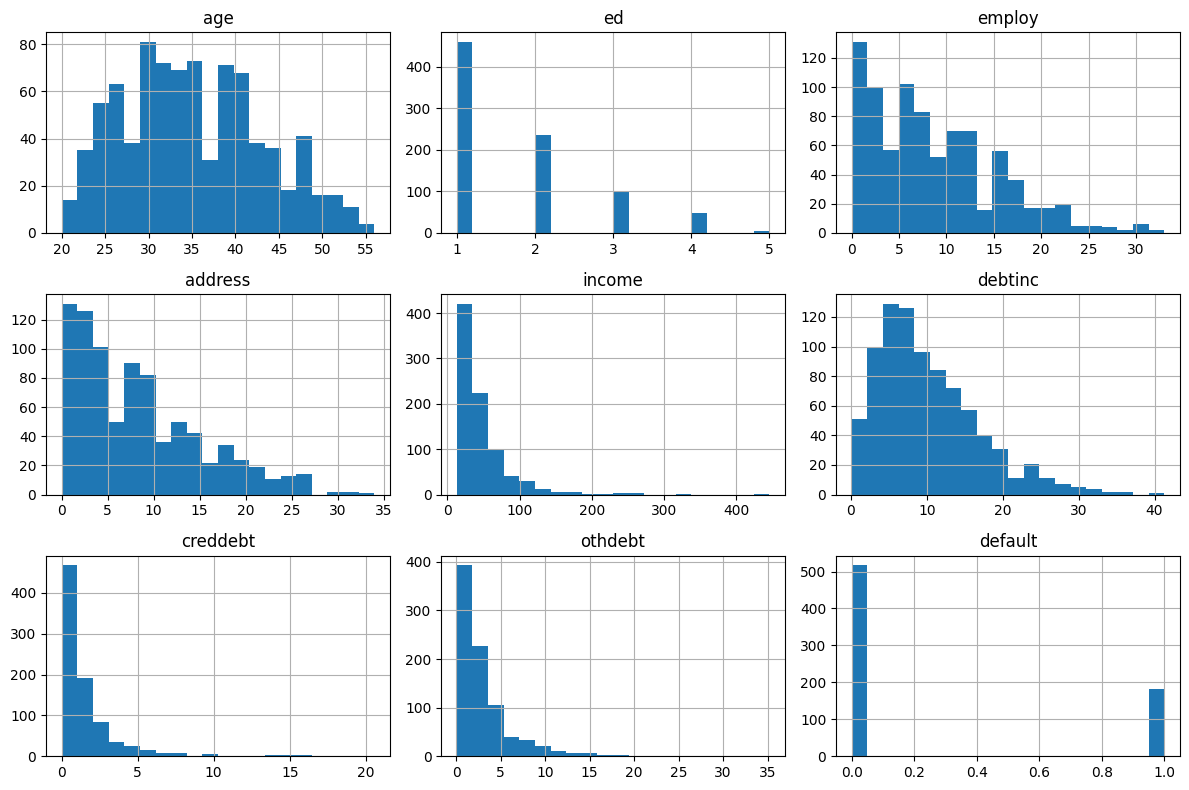

In [5]:
# Histograms of numerical features
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

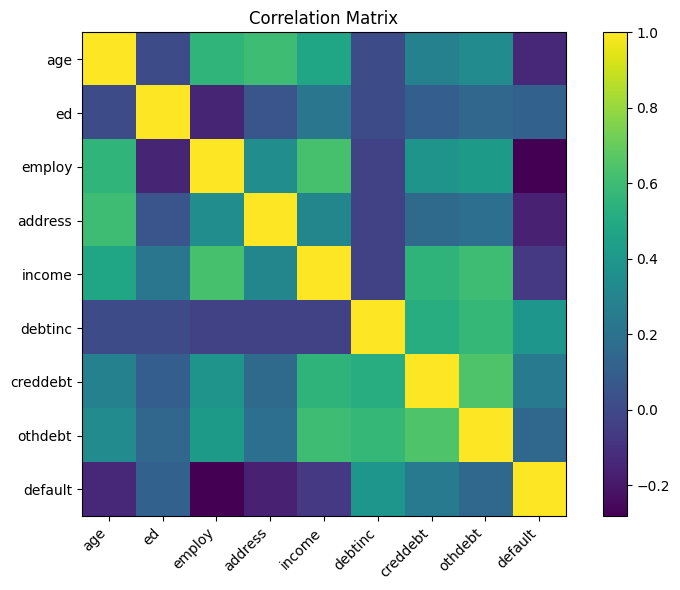

In [6]:
# Correlation matrix to see relationships
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Data Cleaning

In this dataset, all columns are numeric. We still:
- Ensure the target column `default` is integer (0/1)
- Drop any rows with missing values (if present).


In [7]:
# Drop rows with missing values (if any)
df_clean = df.dropna().copy()

# Ensure target is integer type
df_clean['default'] = df_clean['default'].astype(int)

df_clean.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1
1,27,1,10,6,31,17.3,1.362202,4.000798,0
2,40,1,15,14,55,5.5,0.856075,2.168925,0
3,41,1,15,14,120,2.9,2.658720,0.821280,0
4,24,2,2,0,28,17.3,1.787436,3.056564,1


## Task 2 – Feature Engineering and Scaling

I created a few new features to potentially improve predictive power:
- `total_debt` = `creddebt` + `othdebt`
- `debt_to_income_ratio` = `total_debt` / (`income` + 1)  (to avoid division by zero)
- `long_employment_flag` = 1 if `employ` >= 10 years, else 0

In [8]:
df_fe = df_clean.copy()

# New engineered features
df_fe['total_debt'] = df_fe['creddebt'] + df_fe['othdebt']
df_fe['debt_to_income_ratio'] = df_fe['total_debt'] / (df_fe['income'] + 1)
df_fe['long_employment_flag'] = (df_fe['employ'] >= 10).astype(int)

df_fe.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,total_debt,debt_to_income_ratio,long_employment_flag
0,41,3,17,12,176,9.3,11.359392,5.008608,1,16.368,0.092475,1
1,27,1,10,6,31,17.3,1.362202,4.000798,0,5.363,0.167594,1
2,40,1,15,14,55,5.5,0.856075,2.168925,0,3.025,0.054018,1
3,41,1,15,14,120,2.9,2.658720,0.821280,0,3.480,0.028760,1
4,24,2,2,0,28,17.3,1.787436,3.056564,1,4.844,0.167034,0


## Train–Test Split and Scaling Setup

I separate features (X) and target (y), then create train/test splits. Scaling will be done within a `Pipeline` so that it is properly applied during both training and testing.

In [9]:
# Features and target
X = df_fe.drop(columns=['default'])
y = df_fe['default']

feature_names = X.columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((490, 11), (210, 11))

## Task 3 – Model Building and Evaluation (Random Forest)

I built a `RandomForestClassifier` inside a pipeline with `StandardScaler`. Even though tree-based models do not strictly require scaling, we include it to meet the assignment requirement and ensure consistent feature scaling.

In [10]:
# Pipeline: Scaling + Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8047619047619048

Confusion Matrix:
 [[137  18]
 [ 23  32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       155
           1       0.64      0.58      0.61        55

    accuracy                           0.80       210
   macro avg       0.75      0.73      0.74       210
weighted avg       0.80      0.80      0.80       210



### Feature Importance

I inspected feature importance from the trained Random Forest model.

In [11]:
# Extract feature importances from the trained Random Forest
rf_model = rf_pipeline.named_steps['rf']
importances = rf_model.feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
fi

,0
debt_to_income_ratio,0.138664
employ,0.138099
creddebt,0.121932
debtinc,0.117377
total_debt,0.095021
othdebt,0.089698
age,0.084098
address,0.080985
income,0.074620
long_employment_flag,0.033173


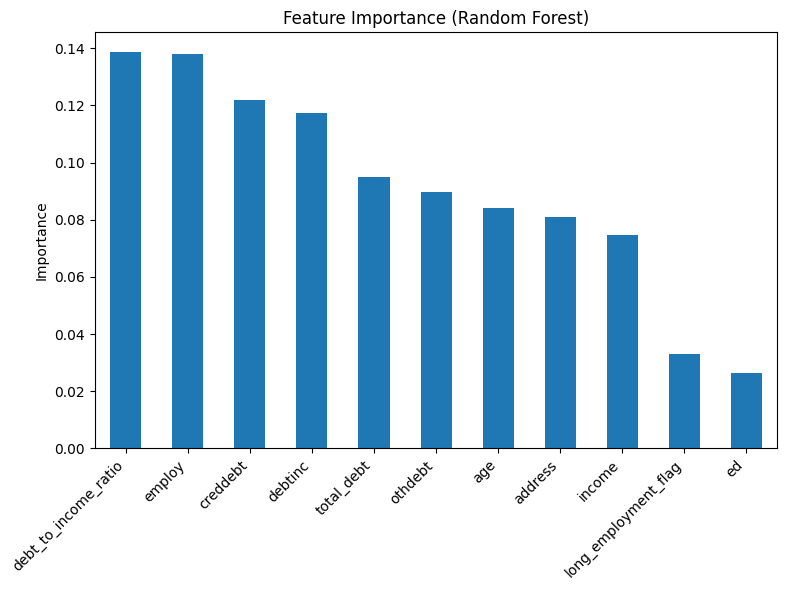

In [12]:
# Plot feature importance
plt.figure(figsize=(8, 6))
fi.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Task 4 – SHAP Explainability and Fairness Analysis

I now use SHAP to understand global and local feature contributions, and then assess model fairness across age groups.

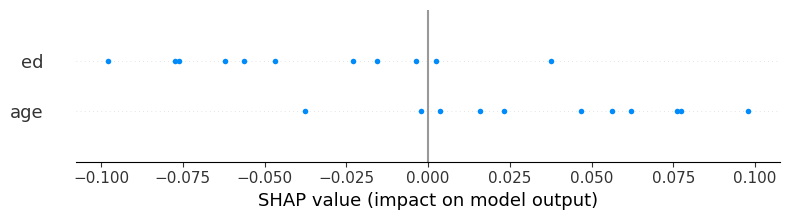

In [20]:
# Prepare data for SHAP
X_train_scaled = rf_pipeline.named_steps['scaler'].transform(X_train)
X_test_scaled  = rf_pipeline.named_steps['scaler'].transform(X_test)

rf_model = rf_pipeline.named_steps['rf']

import shap
shap.initjs()

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Make sure feature names length matches SHAP feature dimension
n_shap_features = shap_values[1].shape[1]
feature_names_shap = feature_names[:n_shap_features]

# --- Global SHAP summary plot (NO feature matrix passed) ---
shap.summary_plot(
    shap_values[1],                # SHAP values matrix (n_samples, n_features)
    feature_names=feature_names_shap,
    max_display=15
)


/usr/local/lib/python3.12/dist-packages/shap/plots/_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


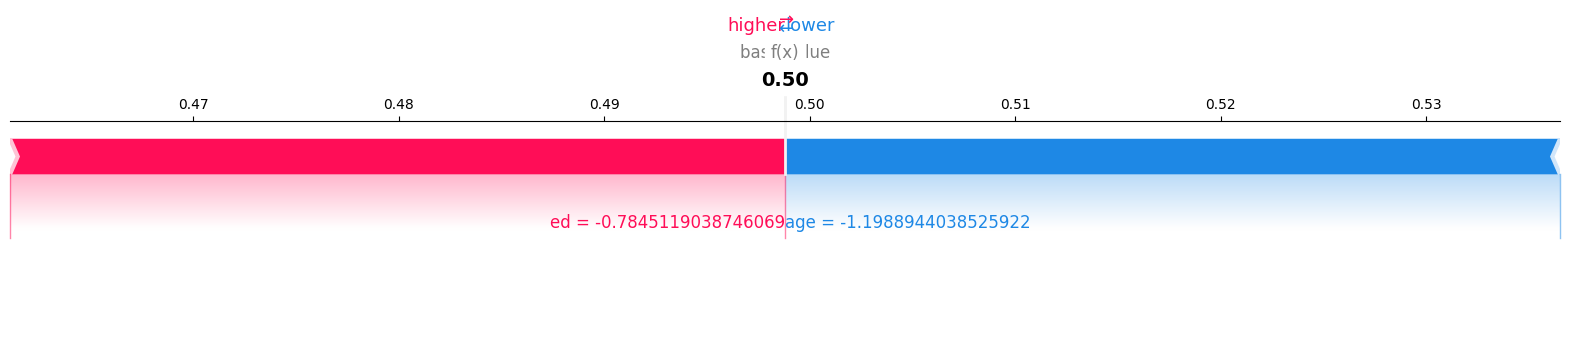

In [22]:
# Local explanation for a single instance
idx = 0

# Make the feature vector match the SHAP vector length
X_instance = X_test_scaled[idx, :n_shap_features]

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][idx, :],
    X_instance,
    feature_names=feature_names_shap,
    matplotlib=True
)

### Fairness Analysis Across Age Groups

This dataset does not contain an explicit gender column, so we use **age group** as the demographic attribute. We define three age groups:
- **Young**: age < 30
- **Middle**: 30 ≤ age < 45
- **Older**: age ≥ 45

We can now compare metrics (accuracy, TPR, FPR) across these groups.

In [23]:
# Create age group column on the full feature-engineered dataframe
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[0, 30, 45, 100],
    labels=['Young', 'Middle', 'Older']
)

# Align age_group with train/test indices
age_group = df_fe['age_group']
age_train = age_group.loc[X_train.index]
age_test = age_group.loc[X_test.index]

# DataFrame with predictions and groups
results = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'age_group': age_test
})

results.head()

,y_true,y_pred,age_group
629,0,0,Young
641,0,0,Older
39,0,0,Middle
461,1,0,Young
200,0,0,Young


In [24]:
# Compute per-group metrics: accuracy, TPR, FPR
group_metrics = []

for group, grp_df in results.groupby('age_group'):
    if grp_df.shape[0] == 0:
        continue
    y_true_g = grp_df['y_true']
    y_pred_g = grp_df['y_pred']
    tn, fp, fn, tp = confusion_matrix(y_true_g, y_pred_g).ravel()
    acc_g = (tp + tn) / (tp + tn + fp + fn)
    tpr_g = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall
    fpr_g = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    group_metrics.append({
        'age_group': group,
        'accuracy': acc_g,
        'TPR': tpr_g,
        'FPR': fpr_g
    })

gm_df = pd.DataFrame(group_metrics)
gm_df

/tmp/ipython-input-1645723495.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, grp_df in results.groupby('age_group'):


,age_group,accuracy,TPR,FPR
0,Young,0.750000,0.629630,0.162162
1,Middle,0.840000,0.545455,0.097087
2,Older,0.761905,0.500000,0.133333


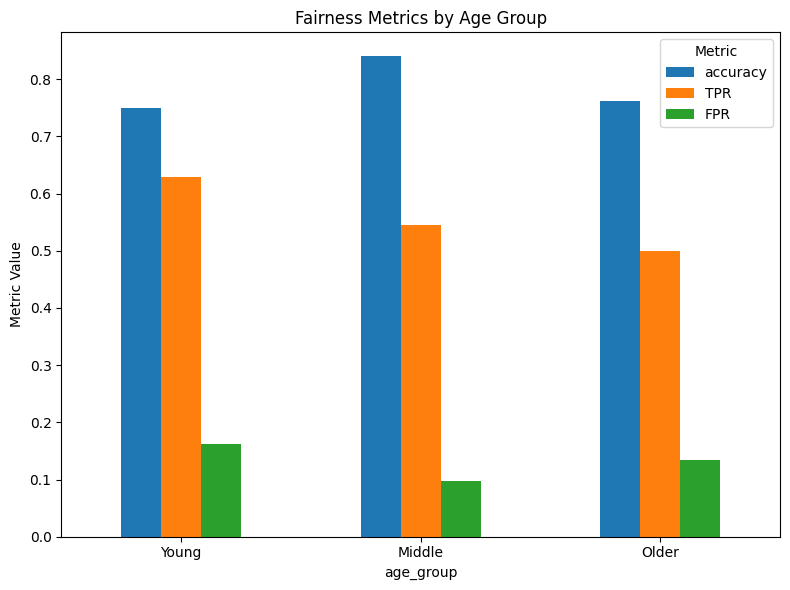

In [25]:
# Plot grouped bar chart of fairness metrics by age group
gm_df_plot = gm_df.set_index('age_group')
ax = gm_df_plot.plot(kind='bar', figsize=(8, 6))
plt.title('Fairness Metrics by Age Group')
plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
